<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=300807538" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import sys
import importlib

# 1. Nettoyage et téléchargement du nouveau pipeline
# Remplace par l'URL de ta branche où tu vas pousser le nouveau data_pipeline.py
GITHUB_RAW_URL = "https://raw.githubusercontent.com/wekt2k04/NeuroSight_AI/main/notebooks/data_pipeline.py"

print("📥 Mise à jour du pipeline NeuroSight...")
!wget -q -O data_pipeline.py {GITHUB_RAW_URL}

if '/kaggle/working' not in sys.path:
    sys.path.append('/kaggle/working')

# 2. Importation dynamique
try:
    import data_pipeline
    importlib.reload(data_pipeline)
    from data_pipeline import prepare_data, show_sample_batch, plot_class_distribution
    print("✅ Pipeline 'Feature Engineered' chargé avec succès.")
except Exception as e:
    print(f"❌ Erreur d'import : {e}")

📥 Mise à jour du pipeline NeuroSight...
✅ Pipeline 'Feature Engineered' chargé avec succès.


📖 1. Chargement des données cliniques et Imputation MICE...
   ✅ Imputation des valeurs manquantes terminée (MICE).
🔍 2. Scan du dossier d'images : /kaggle/input/datasets/ninadaithal/imagesoasis/Data
   ✅ 47580 images valides associées avec succès.

🛡️ 3. Application du Group Split par ID Patient (Validation: 20.0%)...
   📊 Patients uniques Train : 160
   📊 Patients uniques Val   : 40
   🚨 Chevauchement (Leakage): 0 patients (Doit être 0).

⚖️ 4. Calcul des poids pour l'équilibrage des classes (WeightedRandomSampler)...
🚀 Pipeline prêt ! Les DataLoaders vont générer des lots (Images, Labels).

🚀 Classes prêtes : ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']


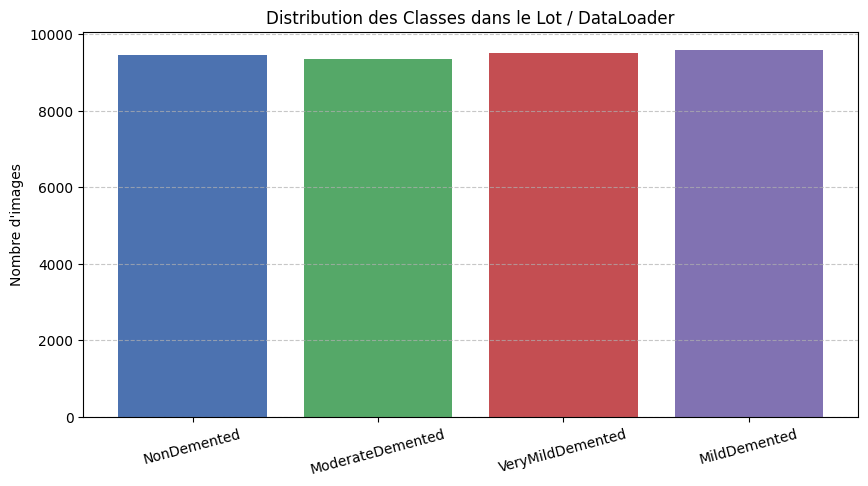

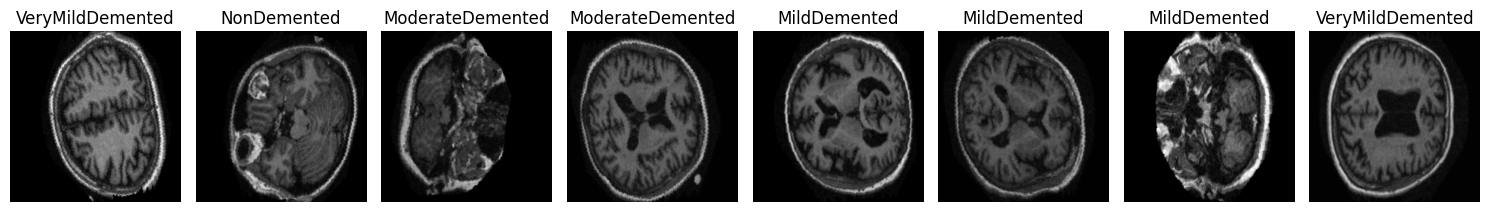

In [4]:
# --- CONFIGURATION DES CHEMINS ---
# Assure-toi que ces chemins correspondent à tes inputs Kaggle
CSV_PATH = '/kaggle/input/datasets/wilfriedtsetse04/mon-csv-officiel/oasis_cross-sectional-5708aa0a98d82080.xlsx'
IMAGES_DIR = '/kaggle/input/datasets/ninadaithal/imagesoasis/Data'

# --- CRÉATION DES LOADERS ---
# Note : on utilise la nouvelle fonction 'prepare_data'
train_loader, val_loader, classes = prepare_data(
    csv_path=CSV_PATH, 
    images_dir=IMAGES_DIR, 
    batch_size=32
)

# --- AUDIT VISUEL ---
print(f"\n🚀 Classes prêtes : {classes}")
plot_class_distribution(train_loader, classes)
show_sample_batch(train_loader, classes)

In [ ]:
# Week 2 :Start coding here !